In [7]:
import os

import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import parcels

import src.load_copernics_fieldset as load_copernics_fieldset  # noqa: E402
from src.saws_functions import sarg_grid_from_sat  # noqa: E402
from src.sargassum_kernels import SargassumParticle  # noqa: E402
import src.sargassum_kernels as sargassum_kernels  # noqa: E402


In [8]:
start_images = [
    {
        'image_name': "../SaWSdata/C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -63.0, -38.0],
    },
    {
        'image_name': "../SaWSdata/C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -11.5, -38.0],
    }
]
release_lon, release_lat, _ = sarg_grid_from_sat(start_images, coarse=True)

In [9]:
fieldset = load_copernics_fieldset.create_fieldset()

#TODO these can be removed as fieldset constants
fieldset.add_constant('G', 9.81)  # Gravitational constant [m s-1]
# #Nitrogen half saturation constant
fieldset.add_constant('k_N', 0.001) #mmol/m3
#Overall maximal growth rate (Corbin & Oxenford)
fieldset.add_constant('MGR_SF3', 0.124)
fieldset.add_constant('MGR_SN1', 0.083)
fieldset.add_constant('MGR_SN8', 0.053)
#Set initial weight
fieldset.add_constant('initial_weight', 50) #grams

File /Users/erik/Desktop/FromElena/copernicus_marine_data_cur.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_so.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_thetao.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_no3.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_stokes.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_wind.nc already exists, skipping...
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_cur.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_so.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_thetao.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_no3.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_stokes.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_wind.nc


In [10]:
for k_N in [0.000129, 0.001, 0.01]:
    filename = f"Simulation_Figure3_kN_{k_N}.zarr"

    fieldset.k_N = k_N

    pset = parcels.ParticleSet(
        fieldset=fieldset,
        pclass = SargassumParticle,
        lon = release_lon,
        lat = release_lat,
        z = np.zeros_like(release_lon),
        time = np.datetime64('2024-07-01T00:00:00'),
    )

    pfile = parcels.ParticleFile(
        filename,
        outputdt=np.timedelta64(2, 'h'),
        chunks = (len(release_lon), 50),
    )

    kernels = [
        parcels.kernels.AdvectionRK4,
        sargassum_kernels.di_Stokes_drift,
        sargassum_kernels.windage_drift,
        sargassum_kernels.sargassum_biological_growth_model,
        sargassum_kernels.stranding,
        sargassum_kernels.DeleteOutOfBounds,
    ]

    if not os.path.exists(filename):
        pset.execute(
            kernels,
            runtime=np.timedelta64(31, 'D'),
            dt=np.timedelta64(10, 'm'),
            output_file=pfile,
    )


In [11]:
#Datasets nitrate
ds = [xr.open_zarr(f"Simulation_Figure3_kN_{k_N}.zarr") for k_N in [0.01, 0.001, 0.000129]]

#Calculate time-mean limitation values
timemean_lim_no3 = np.array([E['lim_no3'].mean(dim='obs') for E in ds])

#Selecting timemeans of all no3 data of three simulations
boxplot_list = [timemean_lim_no3[i, :] for i in range(3)]


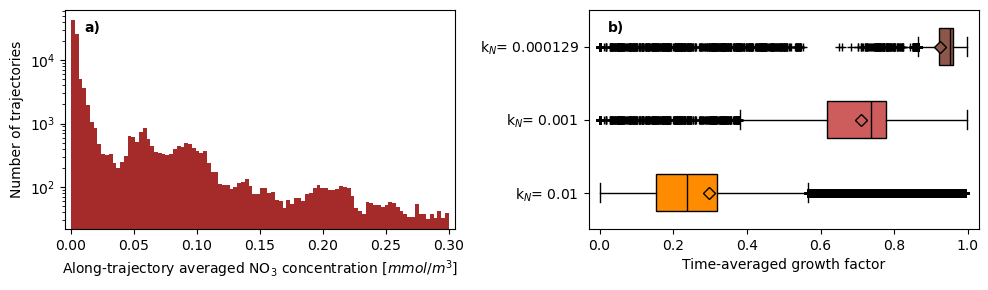

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

no3_timemean = ds[1]['nitrogen'].mean(dim='obs')
ax[0].hist(no3_timemean, bins=100, range=(0, 0.3), log=True, color='brown')
ax[0].set_xlabel('Along-trajectory averaged NO$_3$ concentration [$mmol / m^3$]')
ax[0].set_ylabel('Number of trajectories')
ax[0].set_xlim(-0.005, 0.305)

colors = ['darkorange', 'indianred', 'tab:brown']
names = [f'k$_N$= 0.01', f'k$_N$= 0.001', f'k$_N$= 0.000129']

for i, data in enumerate(boxplot_list):
    ax[1].boxplot(
        data,
        positions=[i],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i]),
        medianprops=dict(color='black'),
        showmeans=True,
        meanprops = dict(marker='D',markeredgecolor='black', markerfacecolor=colors[i]),
        sym='+'
    )

#Assiging labels
for i, name in enumerate(names):
    ax[1].plot([], [], color=colors[i], label=name)
ax[1].set_yticks(range(len(names)))
ax[1].set_yticklabels(names)
ax[1].set_xlabel('Time-averaged growth factor')
ax[1].set_xlim(-0.03,1.03)

for i, label in enumerate(['a)', 'b)']):
    ax[i].text(0.05, 0.95, label, transform=ax[i].transAxes,
               fontsize=10, fontweight='bold', va='top')

plt.tight_layout()
fig.savefig('Figure3.pdf', bbox_inches='tight', dpi=300)
plt.show()